In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import warnings
warnings.filterwarnings('ignore')
from nltk.corpus import stopwords
from dateutil import parser
from datetime import datetime 
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv('emotions_dataset.csv')

In [3]:
df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
df.drop(columns=['id'], inplace=True)

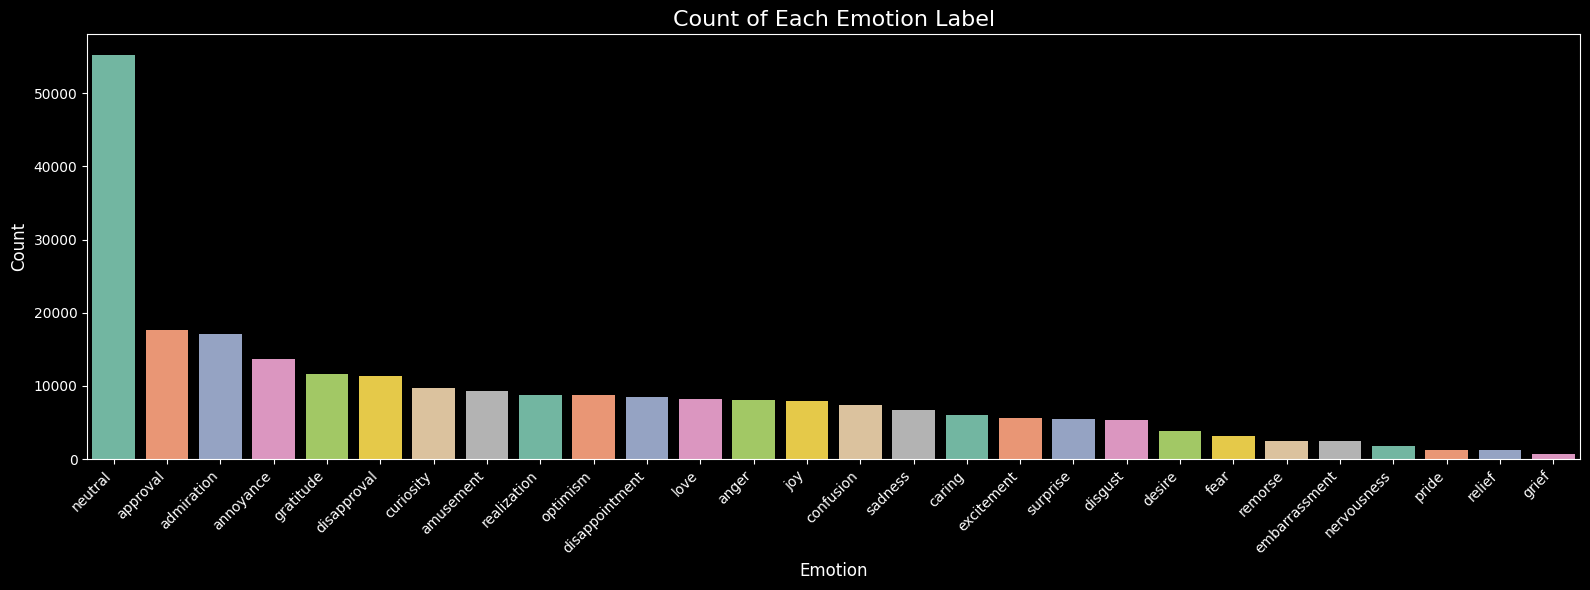

In [5]:
emotion_counts = df.drop(columns=['text', 'example_very_unclear']).sum().sort_values(ascending=False)

# Plot with dark theme
plt.style.use('dark_background')
plt.figure(figsize=(16, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='Set2')

plt.title('Count of Each Emotion Label', fontsize=16, color='white')
plt.xlabel('Emotion', fontsize=12, color='white')
plt.ylabel('Count', fontsize=12, color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

1. Text Preprocessing

In [6]:
slang_df = pd.read_csv('Slang.txt', sep="=", names=["abbreviation", "phrase"], header=None)
slang_df.head()

,abbreviation,phrase
0,A3,"Anytime, Anywhere, Anyplace"
1,ADIH,Another Day In Hell
2,AFK,Away From Keyboard
3,AFAIK,As Far As I Know
4,ASAP,As Soon As Possible


In [7]:
slang_dict = dict(zip(slang_df['abbreviation'], slang_df['phrase'])) 

In [8]:
def translate_slang(text):
    count = 0
    words = text.split()
    new_words = []
    for word in words:
        clean_word = re.sub('[^a-zA-Z0-9-_.]', '', word).upper()
        if clean_word in slang_dict:
            count += 1
            translate_word = slang_dict.get(clean_word, word)
            new_words.append(translate_word)
        else:
            new_words.append(word)
            
    result = ' '.join(new_words)
    
    return result.lower(), count   
 
texts, counts = zip(*df['text'].apply(translate_slang))
df['text'] = texts
df['slang_count'] = counts

In [9]:
df['slang_count'].sum()

np.int64(14163)

2. Handling Temporal Data

In [10]:
def temp_data(text):
    if not isinstance(text, str) or not text:
        return ""
    
    else:
        date_pattern = r'(\d{1,2}\s?[/\-]\s?\d{1,2}\s?[/\-]\s?\d{2,4})|([A-Za-z]{3,9}\s\d{1,2}\s\d{4})'
        def transform_date(match):
            date_str = match.group(0)
            clean_date = re.sub(r'\s+', '', date_str)
            try:
                dt = parser.parse(clean_date, default=datetime(2025, 1, 1))
                return dt.strftime(" %B %d %Y ").lower()
            except:
                return " date_token "
            
        time_pattern = r'\d{1,2}\s?:\s?\d{2}(\s?[ap]m)?'
    
        def transform_time(match):
            time_str = match.group(0).lower()
            clean_time = re.sub(r'\s+', '', time_str)
            try:
                if 'm' in clean_time:
                    parts = clean_time.replace('am', '').replace('pm', '').split(':')
                    hour = int(parts[0])
                    if 'pm' in clean_time and hour != 12:
                        hour += 12
                    elif 'am' in clean_time and hour == 12:
                        hour = 0
                    return f" hour_{hour} "
                return " time_token "
            except:
                return " time_token "

        text = re.sub(date_pattern, transform_date, text)  
        text = re.sub(time_pattern, transform_time, text)  
        
        return " ".join(text.split())
    
df['text'] = df['text'].apply(temp_data)

In [11]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()

def get_pos(tag):
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_and_lemmatize(text):
    if not isinstance(text, str) or not text:
        return ""
    
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(word, get_pos(tag)) for word, tag in pos_tags]
    return " ".join(lemmas)

text = "that game was really hurting my feelings"
print(tokenize_and_lemmatize(text))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


that game be really hurt my feeling


In [12]:
df['text'] = df['text'].apply(tokenize_and_lemmatize)

3. Applying Word2Vec Text Representation

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

# ✅ load model
model_st = SentenceTransformer('all-MiniLM-L6-v2')

# ✅ filter empty texts
df = df[df['text'].str.strip() != ""]

# ✅ encode all texts into embeddings
X = model_st.encode(
    df['text'].tolist(),
    show_progress_bar=True,
    batch_size=64,        # process 64 sentences at a time — RAM efficient
    convert_to_numpy=True
)

y = df.drop(columns=['text', 'example_very_unclear'])

print(f"Feature matrix shape: {X.shape}")  # should be (211225, 384)
print(f"Output shape: {y.shape}")

Feature matrix shape: (211225, 5000)
Output shape: (211225, 29)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np


In [17]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
lr_model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights invers

In [19]:
# Predict
y_pred = lr_model.predict(X_test)

# ---- convert to numpy arrays ----
y_test_array = np.array(y_test)
y_pred_array = np.array(y_pred)

# ---- collect metrics into a list ----
emotion_columns = y.columns.tolist()
metrics = []

for i, emotion in enumerate(emotion_columns):
    report = classification_report(
        y_test_array[:, i], y_pred_array[:, i],
        zero_division=0, output_dict=True
    )
    metrics.append({
        'emotion':   emotion,
        'precision': report['weighted avg']['precision'],
        'recall':    report['weighted avg']['recall'],
        'f1':        report['weighted avg']['f1-score']
    })

---

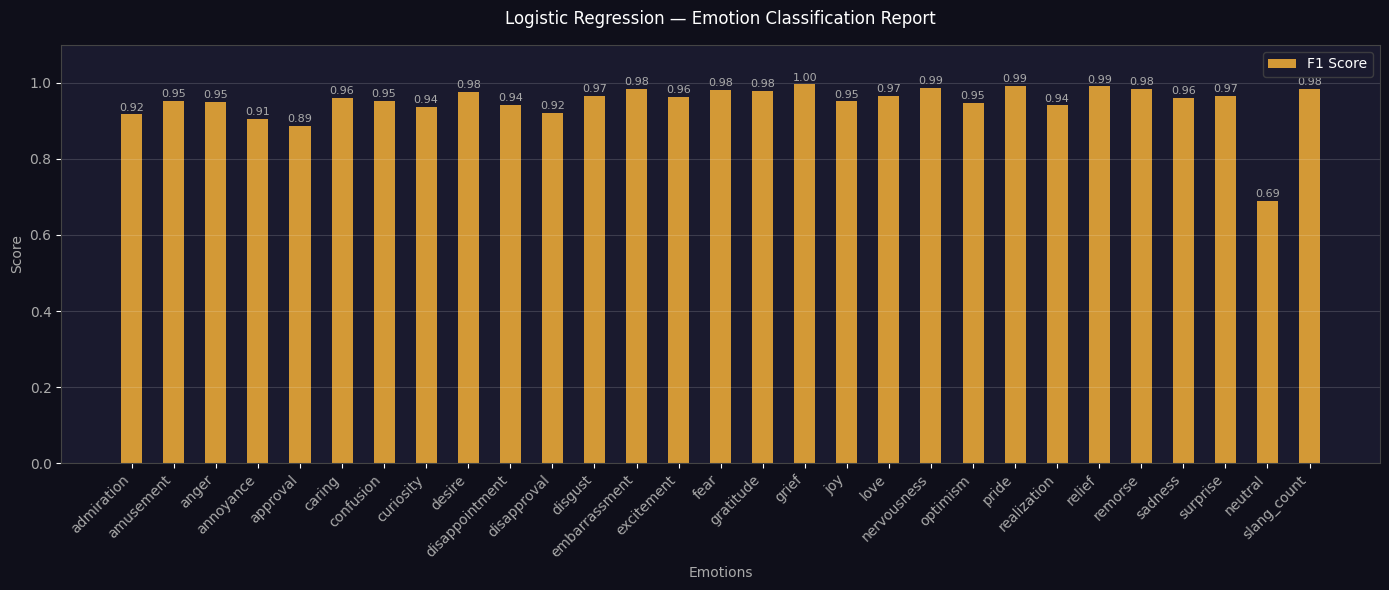

In [21]:
# ---- plot ----
precisions     = [m['precision'] for m in metrics]
recalls        = [m['recall']    for m in metrics]
f1_scores      = [m['f1']        for m in metrics]
emotion_labels = [m['emotion']   for m in metrics]

x = np.arange(len(emotion_labels))
width = 0.25

plt.style.use('dark_background')
plt.figure(figsize=(14, 6))

plt.bar(x, f1_scores, width=0.5, label='F1 Score', color='#E8A838', alpha=0.9)

for i, f in enumerate(f1_scores):
    plt.text(i, f + 0.01, f'{f:.2f}', ha='center', color='#aaaaaa', fontsize=8)

plt.xlabel("Emotions",  color='#aaaaaa')
plt.ylabel("Score",     color='#aaaaaa')
plt.title("Logistic Regression — Emotion Classification Report", color='white', pad=15)
plt.xticks(x, emotion_labels, rotation=45, ha='right', color='#aaaaaa')
plt.yticks(color='#aaaaaa')
plt.ylim(0, 1.1)

plt.gca().set_facecolor('#1a1a2e')
plt.gcf().set_facecolor('#0f0f1a')

plt.gca().spines['bottom'].set_color('#444444')
plt.gca().spines['left'].set_color('#444444')
plt.gca().spines['top'].set_color('#444444')
plt.gca().spines['right'].set_color('#444444')

plt.legend(facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white')
plt.grid(True, alpha=0.15, color='#ffffff', axis='y')
plt.tight_layout()
plt.show()

In [23]:
def preprocess_input(text):
    # ✅ Step 1 — translate slang
    text, _ = translate_slang(text)
    
    # ✅ Step 2 — handle dates and times
    text = temp_data(text)
    
    # ✅ Step 3 — lemmatize
    text = tokenize_and_lemmatize(text)
    
    return text

EXCLUDE = {'slang_count', 'example_very_unclear'}

def predict_emotions(text, threshold=0.3):
    cleaned = preprocess_input(text)
    input_vec = vectorizer.transform([cleaned])
    probs = lr_model.predict_proba(input_vec)
    prob_values = [probs[i][0][1] for i in range(len(emotion_columns))]

    results = {emotion: round(prob, 2) 
               for emotion, prob in zip(emotion_columns, prob_values) 
               if prob >= threshold and emotion not in EXCLUDE}  # ✅ exclude non-emotions
    results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

    print(f"\n🧠 Input:   '{text}'")
    print(f"🔍 Cleaned: '{cleaned}'")
    print(f"🎭 Detected Emotions:")
    if results:
        for emotion, score in results.items():
            bar = '█' * int(score * 20)
            print(f"   {emotion:<20} {bar} {score}")
    else:
        print(f"   No emotion above {threshold} threshold. Try lowering it.")


In [ ]:
faadfsfafafafdafdsafa

In [24]:
predict_emotions("I am so happy and excited today!")
predict_emotions("I feel really lost and sad")
predict_emotions("This makes me so angry, I can't believe it")
predict_emotions("lol that was hilarious omg")  # slang test


🧠 Input:   'I am so happy and excited today!'
🔍 Cleaned: 'i be so happy and excited today !'
🎭 Detected Emotions:
   excitement           ██████████████████ 0.92
   joy                  █████████████████ 0.85

🧠 Input:   'I feel really lost and sad'
🔍 Cleaned: 'i feel really lose and sad'
🎭 Detected Emotions:
   sadness              ████████████████████ 1.0
   disappointment       ███████████████ 0.78

🧠 Input:   'This makes me so angry, I can't believe it'
🔍 Cleaned: 'this make me so angry , i ca n't believe it'
🎭 Detected Emotions:
   No emotion above 0.3 threshold. Try lowering it.

🧠 Input:   'lol that was hilarious omg'
🔍 Cleaned: 'laugh out loud that be hilarious omg'
🎭 Detected Emotions:
   amusement            ████████████████████ 1.0


In [25]:
predict_emotions("I just got promoted at work today! After years of hard work and late nights, my manager finally recognized my efforts. I couldn't stop smiling the entire day. My family is so proud of me!")

predict_emotions("I can't believe they cancelled my favorite show. I had been waiting for months for the new season and now they just pull the plug like it never mattered. The fans deserved so much better than this.")

predict_emotions("I don't know what to do anymore. Everything feels so heavy and I just can't seem to find a reason to keep going. I've been crying all night and nobody even noticed.")

predict_emotions("Wait... so you're telling me that the earth has been around for 4.5 billion years and humans only showed up in the last fraction of that time? That genuinely blows my mind every time I think about it.")

predict_emotions("I messed up really bad today. I forgot my best friend's birthday after they went out of their way to make mine so special last year. I feel absolutely terrible about it.")

predict_emotions("omg lol I literally fell off my chair watching that video LMAO my roommate thought I was dying bro that was the funniest thing I've seen all year no cap")


🧠 Input:   'I just got promoted at work today! After years of hard work and late nights, my manager finally recognized my efforts. I couldn't stop smiling the entire day. My family is so proud of me!'
🔍 Cleaned: 'i just get promote at work today ! after year of hard work and late night , my manager finally recognize my effort . i could n't stop smile the entire day . my family be so proud of me !'
🎭 Detected Emotions:
   No emotion above 0.3 threshold. Try lowering it.

🧠 Input:   'I can't believe they cancelled my favorite show. I had been waiting for months for the new season and now they just pull the plug like it never mattered. The fans deserved so much better than this.'
🔍 Cleaned: 'i ca n't believe they cancel my favorite show . i have be wait for month for the new season and now they just pull the plug like it never matter . the fan deserve so much good than this .'
🎭 Detected Emotions:
   No emotion above 0.3 threshold. Try lowering it.

🧠 Input:   'I don't know what to do an